# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-25: UBFC-Phys Phase-3 Preprocessing

### What this notebook does
Maps the UBFC-Phys dataset (56 subjects x 3 tasks) into the unified Phase-3 schema: one consolidated HDF5 with one group per recording. Frames are decoded from each task video and face-cropped to 72x72; the BVP label is the wrist Empatica-E4 signal (64 Hz) interpolated onto the video frame times.

### Role in Phase 3 - HELD-OUT, not training
UBFC-Phys is a held-out test / validation / stress-probe set, NOT part of the training corpus. Its reference is a wrist Empatica-E4 BVP rather than a finger or contact sensor, and T2/T3 add speech and mental-arithmetic motion on top — the paper itself eliminated 33/56 subjects from T2 and 28/56 from T3. That makes it a weak supervised target but a useful motion-and-stress robustness probe. (Earlier drafts justified this by a very low cardiac SQI; that figure was largely an artefact of scoring a 180 s recording with a 3-bin lobe. At a matched 30 s window UBFC-Phys T1 sits 0.085 from UBFC-rPPG, and 54 of 56 T1 references pass the live_vitals quality gates when windowed — see NB_P3_24 for both measurements.)  Because the role is held-out, ALL recordings are kept (only genuine corruption is dropped) and cardiac_sqi is stored as an informational tag rather than a usability gate.

### Pipeline
s{N}/ -> for each subject and task T1/T2/T3:
  decode vid_s{N}_T{X}.avi -> MediaPipe face box (stable, from sampled frames) -> crop + resize to 72
  bvp_s{N}_T{X}.csv (bare 64 Hz values, 180 s) -> interpolate onto frame times = frame-synced bvp
  eda_s{N}_T{X}.csv (4 Hz) stored raw as optional aux; info + anxiety scores as attributes
  -> write one group per recording into the consolidated UBFC-Phys Phase-3 HDF5:

### Unified Phase-3 schema (v1) — UBFC-Phys specifics
Same grouped 72x72 layout as the other Phase-3 datasets. Each recording group (named `s{N}_T{X}`) holds:

| name | source | present | notes |
|------|--------|---------|-------|
| frames | face-cropped task video | yes | [T, 72, 72, 3] uint8 |
| bvp | wrist E4 BVP (64 Hz, interp to frames) | yes | frame-synced label; noisy wrist reference |
| eda | E4 EDA (4 Hz, raw) | optional | not frame-synced; eda_fs attr |
| ecg / resp / spo2 | - | no (masked) | not provided by UBFC-Phys |

Key attributes: `role='heldout'`, `state` (rest/speech/arithmetic from T1/T2/T3), `scenario` (test/ctrl), `gender`, `cardiac_sqi` (informational), the six self-reported anxiety scores (`anx_*`), and availability flags (`has_bvp`=True, `has_eda`, `has_ecg`/`has_resp`/`has_spo2`=False). `usable` gates only on genuine corruption (duration, exposure, face detection) — NOT on SQI, since this is a held-out set where noisy recordings are the point.

### Frame rate — stored native, not resampled (decision)
UBFC-Phys runs at **35.138 fps** against the 30 fps the Phase-3 models trained on.
Frames are stored at the native rate and `fps` is recorded per group; no temporal
resampling is applied. This is deliberate. The alternatives are both worse: dropping
to 30 fps by nearest-frame selection discards ~15% of frames at irregular intervals,
injecting phase noise into the very signal being measured, while interpolating frames
blurs motion and attenuates a pulse modulation that is already a fraction of a percent
of mean intensity.

The cost is that a 160-frame clip covers **4.55 s** here against 5.33 s in every other
corpus, and the app's `decimation_stride` leaves it untouched because
`round(35.138 / 30) = 1`. Any accuracy difference measured on UBFC-Phys therefore
carries a temporal-extent confound on top of the wrist-reference noise, and must be
reported alongside the numbers rather than compared naively against UBFC-rPPG.

In [7]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import h5py
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

UBFC_PHYS_DIR = Path('E:/UBFC_PHYS_dataset')

# Walk up from the notebook until the repo root is found, identified by the MediaPipe
# asset itself. The previous `Path.cwd().name == 'Notebooks'` test assumed a flat
# notebook folder, but the repo nests them as Notebooks/Phase 3 Notebooks/, so cwd.name
# was 'Phase 3 Notebooks', REPO_ROOT silently became the notebook directory, and the
# failure surfaced three cells later as a FileNotFoundError from inside MediaPipe.
MP_REL = Path('app/live_hr_demo/models/mediapipe/face_landmarker.task')
REPO_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / MP_REL).exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError(f'no {MP_REL} in any parent of {Path.cwd()}')
MP_MODEL = REPO_ROOT / MP_REL

DATASET_NAME = 'ubfc_phys'
# Output beside the source on E:. D: has 59 GB free and holds the repo; the full store
# is roughly 12 GB of gzipped frames across 168 recordings.
OUT_DIR = Path('E:/rppg/phase3')
OUT_H5 = OUT_DIR / f'{DATASET_NAME}_phase3.h5'
LOG_PATH = OUT_DIR / f'processing_log_{DATASET_NAME}_phase3.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = 72 # committed corpus-wide frame size
CROP_PADDING = 0.6 # expand the face box (include forehead + cheeks)
N_DETECT_FRAMES = 12 # frames sampled to compute a stable face box
BVP_FS = 64.0 # Empatica E4 BVP sample rate
EDA_FS = 4.0 # Empatica E4 EDA sample rate
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.7, 3.5
CARDIAC_FLOOR_HZ = 0.15 # SQI lobe floor (~9 bpm); see cardiac_metrics
SQI_WINDOW_S = 30.0 # fixed window for the cross-corpus SQI

# Quality: held-out set -> keep all, gate only on genuine corruption (no SQI floor).
MIN_DURATION_S = 20.0
FRAME_DARK, FRAME_BRIGHT = 5.0, 250.0

SCHEMA_VERSION = 'p3_v1'
ROLE = 'heldout'
TASKS = {'T1': 'rest', 'T2': 'speech', 'T3': 'arithmetic'}
OVERWRITE = False
MAX_RECORDS = None # set to an int for a trial run

print('UBFC-Phys dir exists:', UBFC_PHYS_DIR.exists())
print('MediaPipe model exists:', MP_MODEL.exists())
print('Output store:', OUT_H5)

UBFC-Phys dir exists: True
MediaPipe model exists: True
Output store: E:\rppg\phase3\ubfc_phys_phase3.h5


In [8]:
def cardiac_metrics(sig, fps, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ,
                    floor_hz=CARDIAC_FLOOR_HZ):
    '''Returns cardiac-band spectral HR (bpm) and a peak-power SQI with a floored lobe.

    A bare 3-bin lobe is 3*fps/N wide, so over 180 s it spans 1 bpm and the score
    measures how stationary the heart rate was rather than how clean the signal is.
    Across all 56 T1 recordings it moves 0.14 -> 0.70 between a 180 s and a 10 s window
    with no change to the data, which made this corpus look 2.3x worse than UBFC-rPPG at
    native lengths (0.138 against 0.314) when a matched 30 s window puts them 0.085
    apart. Flooring the lobe at a bandwidth a real heart rate occupies holds the same
    signals at 0.63-0.70 across every window from 180 s down to 10 s, and mirrors
    CONFIDENCE_FLOOR_HZ in the live_vitals app. The floor stops binding at about 10 s,
    where the bin spacing reaches 0.15 Hz on its own.
    '''
    x = np.asarray(sig, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    lobe = max(1, int(round(floor_hz / (freqs[1] - freqs[0]))))
    return (float(freqs[band][pk] * 60.0),
            float(bp[max(0, pk - lobe):pk + lobe + 1].sum() / bp.sum()))


def windowed_metrics(sig, fps, seconds=SQI_WINDOW_S):
    '''Returns median HR and SQI over fixed-length windows, for cross-corpus comparison.

    Corpora differ in recording length, so a whole-recording score compares duration as
    much as quality; fixing the window removes that. The median across windows also
    limits how far one stretch of motion can move the reading -- the whole-recording
    argmax parked several T2/T3 recordings on the 42 bpm band edge, and windowing lifts
    the per-task minima to 46 and 49 bpm. It does not rescue them: T2/T3 medians still
    sit below T1 (66.0 and 72.5 against 81.5) because the recordings that read low are
    the noisy ones. Only pairing within subject, on recordings that clear the SQI gate,
    recovers the direction physiology predicts.
    '''
    n = int(seconds * fps)
    if n > len(sig):
        return cardiac_metrics(sig, fps)
    rows = [cardiac_metrics(sig[i:i + n], fps)
            for i in range(0, len(sig) - n + 1, n)]
    hr = [h for h, _ in rows if np.isfinite(h)]
    return (float(np.median(hr)) if hr else np.nan,
            float(np.median([s for _, s in rows])))


def video_fps(path):
    '''Returns the video frame rate from OpenCV, raising if it cannot be read.

    There is no safe fallback here: fps sets the frame timebase the 64 Hz BVP is
    interpolated onto, so a guessed rate silently misaligns the label for the whole
    recording and nothing downstream can detect it. UBFC-Phys declares 35.138 and
    delivers 35.138 (checked against frame timestamps), so the old 35.0 fallback would
    have been a 0.4% drift with no symptom. process_all catches this per record, so an
    unreadable file is logged as an error rather than stopping the batch.
    '''
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()
    if not fps or fps <= 1.0:
        raise RuntimeError(f'unreadable frame rate for {Path(path).name}')
    return float(fps)


def parse_info(path):
    '''Reads info_s{N}.txt -> (gender, scenario) from its 5 lines (subject, gender, scenario, date, time).'''
    if not path.exists():
        return 'unknown', 'unknown'
    lines = [ln.strip() for ln in path.read_text().splitlines() if ln.strip()]
    gender = lines[1] if len(lines) > 1 else 'unknown'
    scenario = lines[2] if len(lines) > 2 else 'unknown'
    return gender, scenario


def load_anx(path):
    '''Reads selfReportedAnx_s{N}.csv (3x2: cognitive/somatic/confidence, pre/post).

    A missing file yields NaNs and has_anx=False rather than an empty dict. Omitting the
    keys entirely would leave a store where most groups carry anx_* and a few do not,
    which breaks any loader reading them directly and surfaces long after the run that
    could have reported it. s56 ships selfReportedAnx_s55.csv -- an off-by-one naming
    error of the same kind as s40's video.
    '''
    keys = ('anx_cog_pre', 'anx_cog_post', 'anx_som_pre',
            'anx_som_post', 'anx_conf_pre', 'anx_conf_post')
    if not path.exists():
        print(f'    WARNING: {path.name} missing; anx_* recorded as NaN')
        return dict.fromkeys(keys, float('nan')) | dict(has_anx=False)
    a = np.loadtxt(path, delimiter=',')
    return dict(zip(keys, (float(a[0, 0]), float(a[0, 1]), float(a[1, 0]),
                           float(a[1, 1]), float(a[2, 0]), float(a[2, 1])))) | dict(has_anx=True)


def make_landmarker():
    '''Creates a MediaPipe FaceLandmarker in single-image mode.'''
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MP_MODEL)),
        running_mode=mp_vision.RunningMode.IMAGE, num_faces=1)
    return mp_vision.FaceLandmarker.create_from_options(opts)


def stable_face_box(frames_rgb, landmarker, padding=CROP_PADDING):
    '''Returns a square relative face box (rx0, ry0, rx1, ry1) as the median detection over sample frames.'''
    boxes = []
    for frame in frames_rgb:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame))
        res = landmarker.detect(mp_img)
        if not res.face_landmarks:
            continue
        lm = res.face_landmarks[0]
        xs = np.array([p.x for p in lm])
        ys = np.array([p.y for p in lm])
        boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
    if not boxes:
        return None
    x0, y0, x1, y1 = np.median(np.array(boxes), axis=0)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    half = max(x1 - x0, y1 - y0) * (1.0 + padding) / 2.0
    return (cx - half, cy - half, cx + half, cy + half)


def crop_resize(frame_rgb, box, size):
    '''Crops a frame to a relative square box (clamped to the frame) and resizes to size x size.'''
    h, w = frame_rgb.shape[:2]
    x0 = max(0, int(box[0] * w))
    y0 = max(0, int(box[1] * h))
    x1 = min(w, int(box[2] * w))
    y1 = min(h, int(box[3] * h))
    if x1 <= x0 or y1 <= y0:
        return None
    crop = frame_rgb[y0:y1, x0:x1]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)


def extract_face_frames(video_path, landmarker, size=TARGET_SIZE, n_detect=N_DETECT_FRAMES):
    '''Decodes a video, computes a stable face box from sampled frames, and returns cropped size x size frames.'''
    cap = cv2.VideoCapture(str(video_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_total <= 0:
        # Counting is cheap next to the full decode below, and cannot lie. Guessing
        # a count instead sends every detection seek past the end of the file, so
        # the record fails as "face not detected" and hides the real cause.
        probe = cv2.VideoCapture(str(video_path))
        n_total = 0
        while probe.grab():
            n_total += 1
        probe.release()
    sample_at = sorted(set(np.linspace(0, max(n_total - 1, 0), n_detect).astype(int)))
    samples = []
    for i in sample_at:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, bgr = cap.read()
        if ok:
            samples.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    box = stable_face_box(samples, landmarker) if samples else None
    if box is None:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    out = []
    while True:
        ok, bgr = cap.read()
        if not ok:
            break
        c = crop_resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), box, size)
        if c is not None:
            out.append(c)
    cap.release()
    if not out:
        return None
    return np.asarray(out, dtype=np.uint8)

### Single-recording walkthrough
Processes one subject-task end to end (video decode, face-crop, 64 Hz BVP interpolation to frame times) and prints the record numerically. Confirms the frame tensor, the BVP alignment and the metadata attributes before the full batch. No face imagery is rendered.

In [9]:
subject_dirs = sorted([p for p in UBFC_PHYS_DIR.iterdir() if p.is_dir() and p.name.startswith('s')])
print('Subject folders:', len(subject_dirs))

LANDMARKER = make_landmarker()


def build_record(subj_dir, task):
    '''Builds one unified-schema record from a UBFC-Phys subject folder and task (T1/T2/T3).'''
    subject = subj_dir.name
    vid = subj_dir / f'vid_{subject}_{task}.avi'
    bvp_path = subj_dir / f'bvp_{subject}_{task}.csv'
    if not vid.exists() or not bvp_path.exists():
        raise RuntimeError('missing video or bvp')
    frames = extract_face_frames(vid, LANDMARKER)
    if frames is None or len(frames) == 0:
        raise RuntimeError('no frames or face not detected')
    n = len(frames)
    fps = video_fps(vid)
    bvp_raw = np.loadtxt(bvp_path, delimiter=',')
    frame_t = np.arange(n) / fps
    bvp_t = np.arange(len(bvp_raw)) / BVP_FS
    # np.interp holds its endpoints constant outside the input range, so a short
    # or truncated BVP becomes a stretch of flat label rather than an error. The
    # label is the whole point of the record, so disagreement has to be loud.
    if abs(frame_t[-1] - bvp_t[-1]) > 1.0:
        raise RuntimeError(f'video spans {frame_t[-1]:.2f}s but bvp spans '
                           f'{bvp_t[-1]:.2f}s; refusing to clamp the label')
    bvp = np.interp(frame_t, bvp_t, bvp_raw).astype(np.float32)
    bvp_hr, sqi = cardiac_metrics(bvp, fps)
    # The floored whole-recording SQI is comparable across window lengths but still
    # not across corpora of different duration. The 30 s figure is the one to compare
    # UBFC-Phys against DLCN / UBFC-rPPG / MCD with.
    windowed_hr, sqi_30s = windowed_metrics(bvp, fps, SQI_WINDOW_S)
    eda_path = subj_dir / f'eda_{subject}_{task}.csv'
    eda = np.loadtxt(eda_path, delimiter=',').astype(np.float32) if eda_path.exists() else None
    gender, scenario = parse_info(subj_dir / f'info_{subject}.txt')
    duration_s = n / fps
    # Sampled across the recording, not at the midpoint: a capture can be correctly
    # exposed halfway through and blown out or black elsewhere, and this gates `usable`.
    # The median tolerates a single odd frame while still catching a recording that is
    # dark or saturated for a substantial part of its length.
    brightness = float(np.median([frames[i].mean()
                                  for i in np.linspace(0, n - 1, 9).astype(int)]))
    attrs = dict(
        schema_version=SCHEMA_VERSION, dataset='UBFC-Phys', role=ROLE, source_file=vid.name,
        # subject_id stays bare to match every other Phase-3 store ('11'), but UBFC-rPPG
        # also has a subject '11' who is a different person. Any split or index built
        # across stores must key on subject_uid, or on (dataset, subject_id).
        subject_id=subject[1:], subject_uid=f'ubfc_phys_{subject}',
        subject=subject, task=task, state=TASKS[task],
        scenario=scenario, gender=gender,
        fps=float(fps), n_frames=int(n), duration_s=float(duration_s), frame_size=int(TARGET_SIZE),
        has_frames=True, has_bvp=True, has_eda=bool(eda is not None),
        has_hr=False, has_spo2=False, has_resp=False, has_ecg=False,
        cardiac_sqi=float(sqi), cardiac_sqi_30s=float(sqi_30s),
        bvp_spectral_hr=float(bvp_hr) if np.isfinite(bvp_hr) else float('nan'),
        bvp_windowed_hr=float(windowed_hr) if np.isfinite(windowed_hr) else float('nan'),
        bvp_fs=BVP_FS, eda_fs=EDA_FS,
        frame_ok=bool(FRAME_DARK <= brightness <= FRAME_BRIGHT),
        usable=bool(duration_s >= MIN_DURATION_S and FRAME_DARK <= brightness <= FRAME_BRIGHT),
        bvp_units_note='wrist Empatica-E4 BVP (64 Hz) interpolated to frame times; noisy reference, held-out only')
    attrs.update(load_anx(subj_dir / f'selfReportedAnx_{subject}.csv'))
    arrays = dict(bvp=bvp, frames=frames)
    if eda is not None:
        arrays['eda'] = eda
    return f'{subject}_{task}', arrays, attrs


demo = None
for sd in subject_dirs:
    for t in ('T1', 'T2', 'T3'):
        if (sd / f'vid_{sd.name}_{t}.avi').exists():
            demo = (sd, t)
            break
    if demo:
        break

rec_id, arrays, attrs = build_record(*demo)
print('record:', rec_id)
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in attrs.items()}, indent=2, default=str))
print('frames', arrays['frames'].shape, '| bvp', arrays['bvp'].shape,
      '| eda', (arrays['eda'].shape if 'eda' in arrays else None))

Subject folders: 56
record: s1_T1
{
  "schema_version": "p3_v1",
  "dataset": "UBFC-Phys",
  "role": "heldout",
  "source_file": "vid_s1_T1.avi",
  "subject_id": "1",
  "subject_uid": "ubfc_phys_s1",
  "subject": "s1",
  "task": "T1",
  "state": "rest",
  "scenario": "test",
  "gender": "m",
  "fps": 35.138,
  "n_frames": 6325,
  "duration_s": 180.005,
  "frame_size": 72,
  "has_frames": true,
  "has_bvp": true,
  "has_eda": true,
  "has_hr": false,
  "has_spo2": false,
  "has_resp": false,
  "has_ecg": false,
  "cardiac_sqi": 0.418,
  "cardiac_sqi_30s": 0.547,
  "bvp_spectral_hr": 73.998,
  "bvp_fs": 64.0,
  "eda_fs": 4.0,
  "frame_ok": true,
  "usable": true,
  "bvp_units_note": "wrist Empatica-E4 BVP (64 Hz) interpolated to frame times; noisy reference, held-out only",
  "anx_cog_pre": 2.143,
  "anx_cog_post": 3.286,
  "anx_som_pre": 2.571,
  "anx_som_post": 3.428,
  "anx_conf_pre": 2.778,
  "anx_conf_post": 1.778,
  "has_anx": true
}
frames (6325, 72, 72, 3) | bvp (6325,) | eda (72

### Write function and batch processing


In [10]:
def write_group(store, name, arrays, attrs):
    '''Writes one recording as a group with datasets for the present signals and all attributes.'''
    g = store.create_group(name)
    g.create_dataset('frames', data=arrays['frames'], chunks=(32, TARGET_SIZE, TARGET_SIZE, 3),
                     compression='gzip', compression_opts=1)
    g.create_dataset('bvp', data=arrays['bvp'])
    if 'eda' in arrays:
        g.create_dataset('eda', data=arrays['eda'])
    for key, value in attrs.items():
        g.attrs[key] = value


def process_all(subject_dirs, out_h5, tasks=('T1', 'T2', 'T3'), limit=None, overwrite=False):
    '''Processes existing subject-task videos into one consolidated per-dataset HDF5 (one group each).'''
    jobs = [(sd, t) for sd in subject_dirs for t in tasks if (sd / f'vid_{sd.name}_{t}.avi').exists()]
    if limit:
        jobs = jobs[:limit]
    rows = []
    with h5py.File(out_h5, 'a') as store:
        for i, (subj_dir, task) in enumerate(jobs, 1):
            name = f'{subj_dir.name}_{task}'
            if name in store and not overwrite:
                a = dict(store[name].attrs)
                a['status'] = 'skipped'
                a['error'] = ''
            else:
                try:
                    rec_id, arrays, attrs = build_record(subj_dir, task)
                    if name in store:
                        del store[name]
                    write_group(store, name, arrays, attrs)
                    store.flush()
                    a = dict(attrs)
                    a['status'] = 'ok'
                    a['error'] = ''
                except Exception as exc:
                    a = dict(source_file=name, subject=subj_dir.name, task=task,
                             state=TASKS.get(task, ''), cardiac_sqi=np.nan,
                             cardiac_sqi_30s=np.nan, usable=False,
                             status='error', error=str(exc))
            cols = ('source_file', 'subject', 'task', 'state', 'scenario', 'gender', 'n_frames',
                    'fps', 'duration_s', 'cardiac_sqi', 'cardiac_sqi_30s', 'bvp_spectral_hr',
                    'usable', 'status', 'error')
            rows.append({c: a.get(c) for c in cols})
            print('  ', i, '/', len(jobs), name, '->', a.get('status'))
    return pd.DataFrame(rows)


log = process_all(subject_dirs, OUT_H5, limit=MAX_RECORDS, overwrite=OVERWRITE)
log.to_csv(LOG_PATH, index=False)
print('Store:', OUT_H5)
print('Records ok:', int((log.status == 'ok').sum()), '| skipped:', int((log.status == 'skipped').sum()),
      '| errors:', int((log.status == 'error').sum()))
print('Usable:', int(log['usable'].sum()), '/', len(log))
print('Log ->', LOG_PATH)

   1 / 168 s1_T1 -> skipped
   2 / 168 s1_T2 -> skipped
   3 / 168 s1_T3 -> skipped
   4 / 168 s10_T1 -> skipped
   5 / 168 s10_T2 -> skipped
   6 / 168 s10_T3 -> skipped
   7 / 168 s11_T1 -> skipped
   8 / 168 s11_T2 -> skipped
   9 / 168 s11_T3 -> skipped
   10 / 168 s12_T1 -> skipped
   11 / 168 s12_T2 -> skipped
   12 / 168 s12_T3 -> skipped
   13 / 168 s13_T1 -> skipped
   14 / 168 s13_T2 -> skipped
   15 / 168 s13_T3 -> skipped
   16 / 168 s14_T1 -> skipped
   17 / 168 s14_T2 -> skipped
   18 / 168 s14_T3 -> skipped
   19 / 168 s15_T1 -> skipped
   20 / 168 s15_T2 -> skipped
   21 / 168 s15_T3 -> skipped
   22 / 168 s16_T1 -> skipped
   23 / 168 s16_T2 -> skipped
   24 / 168 s16_T3 -> skipped
   25 / 168 s17_T1 -> skipped
   26 / 168 s17_T2 -> skipped
   27 / 168 s17_T3 -> skipped
   28 / 168 s18_T1 -> skipped
   29 / 168 s18_T2 -> skipped
   30 / 168 s18_T3 -> skipped
   31 / 168 s19_T1 -> skipped
   32 / 168 s19_T2 -> skipped
   33 / 168 s19_T3 -> skipped
   34 / 168 s2_T1 -> s

### Output validation
Re-opens the consolidated store, confirms the schema, verifies the frame tensor numerically (no face rendering), plots one BVP, and summarises cardiac SQI by task (the expected clean-to-noisy order is rest > speech > arithmetic).

Groups in ubfc_phys_phase3.h5 : 168
Example group: s10_T1
  datasets: ['bvp', 'eda', 'frames']
  attrs: {'anx_cog_post': np.float64(2.714), 'anx_cog_pre': np.float64(2.143), 'anx_conf_post': np.float64(1.778), 'anx_conf_pre': np.float64(2.222), 'anx_som_post': np.float64(2.428), 'anx_som_pre': np.float64(1.714), 'bvp_fs': np.float64(64.0), 'bvp_spectral_hr': np.float64(90.33104822134386), 'bvp_units_note': 'wrist Empatica-E4 BVP (64 Hz) interpolated to frame times; noisy reference, held-out only', 'cardiac_sqi': np.float64(0.7003187087987177), 'cardiac_sqi_30s': np.float64(0.6709889365569903), 'dataset': 'UBFC-Phys', 'duration_s': np.float64(180.00455347487053), 'eda_fs': np.float64(4.0), 'fps': np.float64(35.138), 'frame_ok': np.True_, 'frame_size': np.int64(72), 'gender': 'f', 'has_anx': np.True_, 'has_bvp': np.True_, 'has_ecg': np.False_, 'has_eda': np.True_, 'has_frames': np.True_, 'has_hr': np.False_, 'has_resp': np.False_, 'has_spo2': np.False_, 'n_frames': np.int64(6325), 'role'

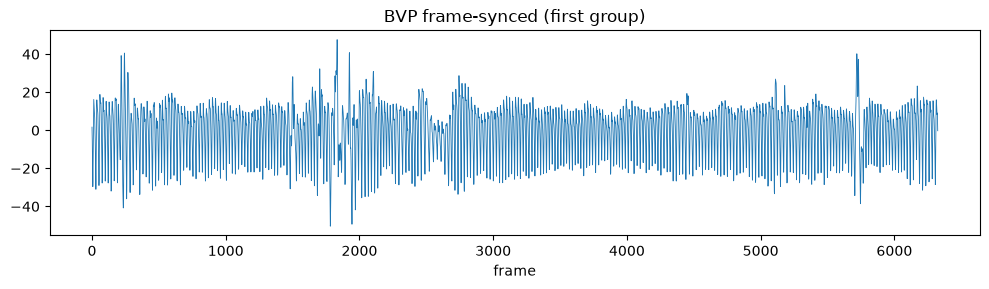

Records ok: 0 | errors: 0
Usable: 168 / 168


In [11]:
if OUT_H5.exists():
    with h5py.File(OUT_H5, 'r') as store:
        groups = sorted(store.keys())
        print('Groups in', OUT_H5.name, ':', len(groups))
        g0 = store[groups[0]]
        print('Example group:', groups[0])
        print('  datasets:', list(g0.keys()))
        print('  attrs:', dict(g0.attrs))
        fr = g0['frames']
        print('  frames:', fr.shape, fr.dtype, 'range', int(fr[0].min()), '-', int(fr[0].max()))
        bvp0 = g0['bvp'][:]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(len(bvp0)), bvp0, lw=0.6)
    ax.set_title('BVP frame-synced (first group)')
    ax.set_xlabel('frame')
    plt.tight_layout()
    plt.show()

if len(log):
    print('Records ok:', int((log.status == 'ok').sum()), '| errors:', int((log.status == 'error').sum()))
    print('Usable:', int(log['usable'].sum()), '/', len(log))
    ok = log[log.status == 'ok']
    if len(ok):
        print('Cardiac SQI by task (rest/speech/arithmetic):')
        print(ok.groupby('state')[['cardiac_sqi', 'cardiac_sqi_30s']]
                .agg(['median', 'min', 'max']).round(3))

In [12]:
print(len(log), 'rows'); print(log.status.value_counts())

168 rows
status
skipped    168
Name: count, dtype: int64


In [13]:
expected = {f'{sd.name}_{t}' for sd in subject_dirs for t in ('T1', 'T2', 'T3')
            if (sd / f'vid_{sd.name}_{t}.avi').exists()}
with h5py.File(OUT_H5, 'r') as store:
    got = set(store.keys())
print(f'{len(got)} groups, {len(expected)} expected')
print('missing:', sorted(expected - got) or 'none')
print('unexpected:', sorted(got - expected) or 'none')

168 groups, 168 expected
missing: none
unexpected: none
